# Import Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create and load the Toy Two Moons Dataset

In [2]:
# Adjust the n_samples and the noise to have the distribution you want
X, y = make_moons(n_samples=1200, noise=10, random_state=42)

# Split into Train/Test

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale Features (Important for SVM and KNN)

In [4]:
# Scale features (important for SVM & k-NN)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

# Define Models

In [5]:
models = {
    "SVM (linear)": SVC(kernel="linear", C=1.0, random_state=42),
    "SVM (RBF)":    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
    "k-NN (k=15)":  KNeighborsClassifier(n_neighbors=15, weights="distance"),
    "k-NN (k=50)":  KNeighborsClassifier(n_neighbors=15, weights="distance")
}

# Helper: plot decision boundary

In [6]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.25, levels=np.arange(y.max()+2)-0.5)
    plt.contour(xx, yy, Z, colors='k', linewidths=0.1)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

#  Train, evaluate, and plot each model

SVM (linear) Test Accuracy: 0.539


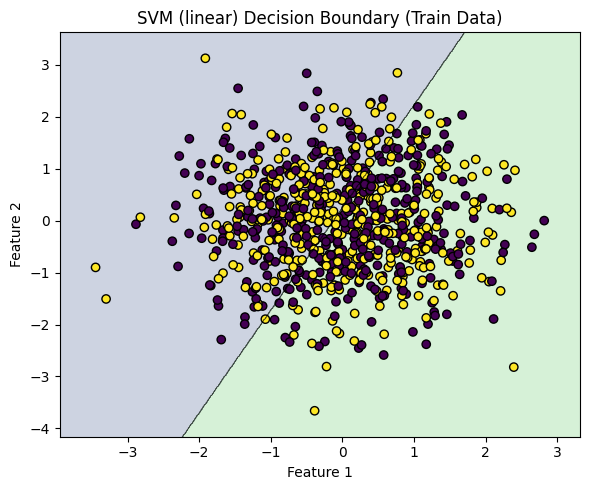

SVM (RBF) Test Accuracy: 0.503


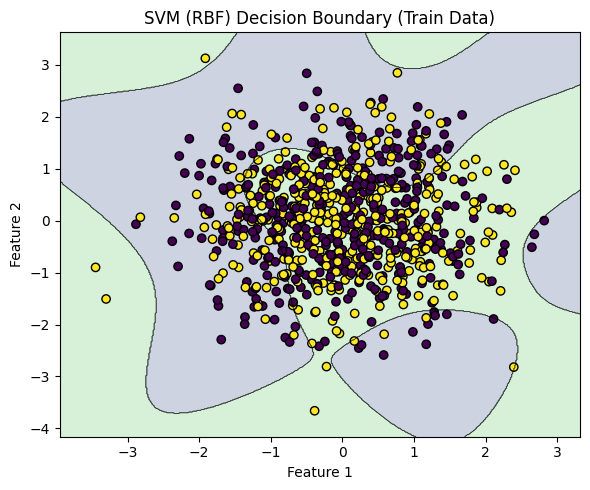

k-NN (k=15) Test Accuracy: 0.494


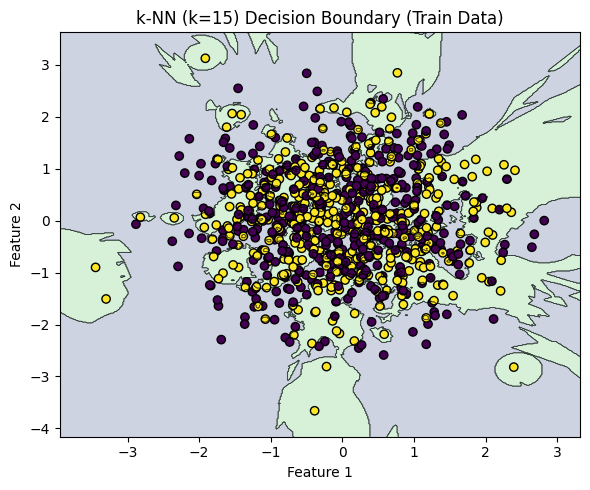

k-NN (k=50) Test Accuracy: 0.494


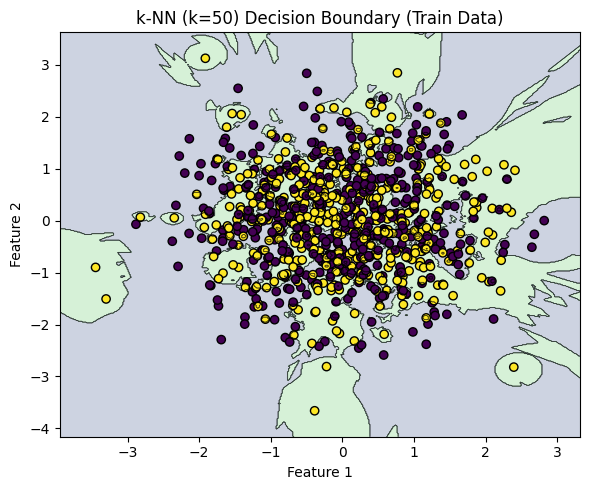

In [7]:
for name, model in models.items():
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    print(f"{name} Test Accuracy: {acc:.3f}")
    plot_decision_boundary(model, X_train_s, y_train, f"{name} Decision Boundary (Train Data)")